In [27]:
#!/usr/bin/env python3
import os
import scipy.io as sio
import numpy as np
import pandas as pd

# ——— PARAMETERS ———
csv_file     = "/home/lq53/mir_repos/dappy_24_nov/mir_modif_dappy/meta_datas/sum3folder_20250526_rerun.csv"
speed_thresh = 0.5  # threshold for defining a movement bout

# ——— HELPERS ———
def get_session_root(pred_path):
    # from .../DANNCE/predict00/... go up three levels
    return os.path.abspath(
        os.path.join(pred_path, os.pardir, os.pardir, os.pardir)
    )

def get_com_path(session_root):
    return os.path.join(session_root, "COM", "predict00", "com3d0.mat")

def segment_bouts(com, speed_thresh):
    speeds = np.linalg.norm(np.diff(com, axis=0), axis=1)
    bouts = 0
    in_bout = False
    for s in speeds:
        if s > speed_thresh and not in_bout:
            bouts += 1
            in_bout = True
        elif s <= speed_thresh:
            in_bout = False
    return bouts

# ——— MAIN ———
# 1. load metadata and filter out any session whose path contains "juneon"
meta = pd.read_csv(csv_file)
baseline = meta[~meta["Prediction_path"].str.contains("juneon", na=False)].copy()

records = []
session_count = 0
fps = 30.0
dt  = 1.0 / fps   # ≈0.0333 s
for _, row in baseline.iterrows():
    session_count += 1
    pred = row["Prediction_path"]
    sess = get_session_root(pred)
    com_f = get_com_path(sess)

    try:
        mat = sio.loadmat(com_f)
        com = mat["com"]   # shape (T,3)
    except Exception as e:
        print(f"Skipping {sess!r}: {e}")
        continue

    # compute step displacements
    dxyz = np.diff(com, axis=0)
    speeds = np.linalg.norm(dxyz, axis=1) / dt

    # 1. Mean speed
    speed_mean = speeds.mean()

    # 2. Mean turn angle
    if dxyz.shape[0] >= 2:
        v1, v2 = dxyz[:-1], dxyz[1:]
        n1, n2 = np.linalg.norm(v1, axis=1), np.linalg.norm(v2, axis=1)
        valid = (n1 > 0) & (n2 > 0)
        cosang = np.einsum("ij,ij->i", v1[valid], v2[valid]) / (n1[valid] * n2[valid])
        turn_ang_mean = np.arccos(np.clip(cosang, -1, 1)).mean()
    else:
        turn_ang_mean = np.nan

    # 3. Straightness
    total_dist = speeds.sum()
    net_disp   = np.linalg.norm(com[-1] - com[0])
    straightness = net_disp / total_dist if total_dist > 0 else np.nan

    # 4. Radius of gyration
    center = com.mean(axis=0)
    rg     = np.sqrt(np.mean(np.sum((com - center) ** 2, axis=1)))

    # 5. Bout count
    bout_count = segment_bouts(com, speed_thresh)

    records.append({
        "session_root": sess,
        "speed_mean": speed_mean,
        "turn_ang_mean": turn_ang_mean,
        "straightness": straightness,
        "radius_gyration": rg,
        "bout_count": bout_count,
    })

# assemble and display
df = pd.DataFrame.from_records(records)
print("COM movement metrics (excluding any 'juneon' sessions):")
print(df.to_string(index=False))

# save for downstream use
out_file = "com_baseline_metrics.csv"
df.to_csv(out_file, index=False)
print(f"\nSaved metrics to {out_file}")

print("session_count", session_count)

COM movement metrics (excluding any 'juneon' sessions):
                                                                                session_root  speed_mean  turn_ang_mean  straightness  radius_gyration  bout_count
                                  /data/big_rim/rsync_dcc_sum/24summ/2024_06_26/1686940_left  102.212954       1.185668      0.000149     4.053829e+02        5165
                                 /data/big_rim/rsync_dcc_sum/24summ/2024_06_26/1686940_left2   57.268944       1.495061      0.000178     2.708663e+02        7854
                              /data/big_rim/rsync_dcc_sum/24summ/2024_06_26/1686940_no_holes   81.273925       1.327535      0.000079     3.932853e+02        6131
                                  /data/big_rim/rsync_dcc_sum/24summ/2024_06_27/1686941_left   84.713269       1.369670      0.000167     4.605231e+02        6467
                          /data/big_rim/rsync_dcc_sum/24summ/2024_06_28/1686941_left_right_2   58.704906       1.588200      0.00

/tmp/ipykernel_495653/3562161590.py:68: RuntimeWarning: Mean of empty slice.
  turn_ang_mean = np.arccos(np.clip(cosang, -1, 1)).mean()
/home/lq53/miniconda3/envs/bbop241209/lib/python3.9/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


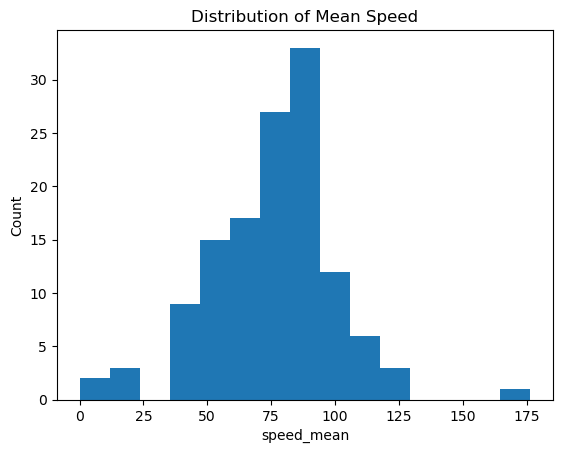

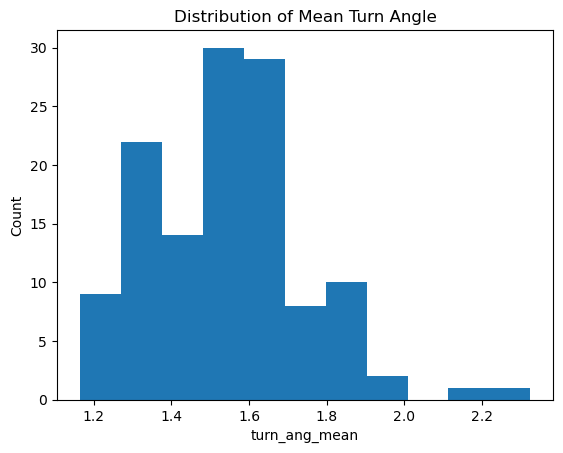

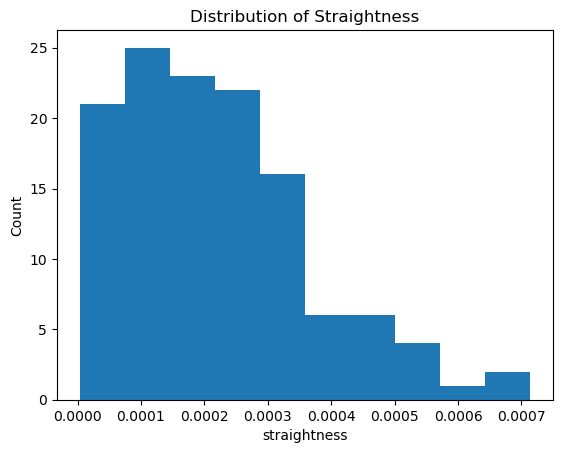

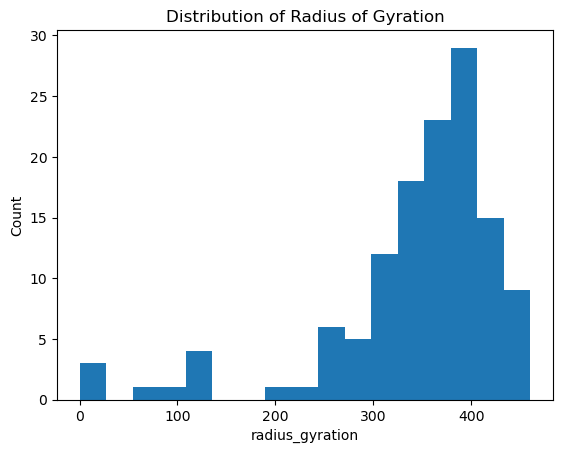

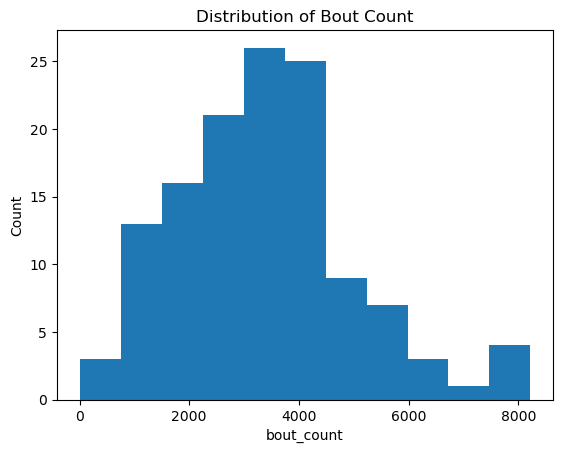

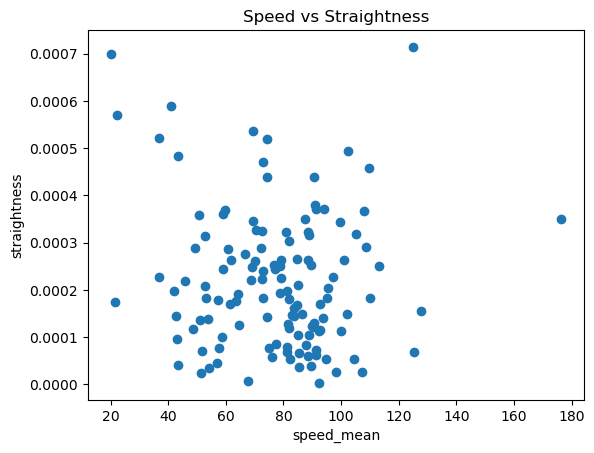

In [28]:
import matplotlib.pyplot as plt

# List of the five metrics
metrics = [
    ("Mean Speed",        "speed_mean"),
    ("Mean Turn Angle",   "turn_ang_mean"),
    ("Straightness",      "straightness"),
    ("Radius of Gyration","radius_gyration"),
    ("Bout Count",        "bout_count")
]

# 1) Histograms
for title, col in metrics:
    plt.figure()
    plt.hist(df[col].dropna(), bins='auto')
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.title(f"Distribution of {title}")
    plt.show()

# 2) Example bivariate scatter: Speed vs Straightness
plt.figure()
plt.scatter(df["speed_mean"], df["straightness"])
plt.xlabel("speed_mean")
plt.ylabel("straightness")
plt.title("Speed vs Straightness")
plt.show()


In [6]:
import pandas as pd
from scipy.stats import skew, kurtosis

# assume df is already in memory
summary = []
for col in ["speed_mean", "turn_ang_mean", "straightness", "radius_gyration", "bout_count"]:
    data = df[col].dropna()
    summary.append({
        "metric":       col,
        "mean":         data.mean(),
        "median":       data.median(),
        "std":          data.std(ddof=1),
        "skewness":     skew(data),
        "kurtosis":     kurtosis(data, fisher=True),  # excess kurtosis
    })
pd.DataFrame(summary).set_index("metric")


,mean,median,std,skewness,kurtosis
metric,,,,,
speed_mean,2.544793,2.666164,0.829831,-0.087524,2.079203
turn_ang_mean,1.541776,1.556205,0.203481,0.601475,1.217082
straightness,0.006596,0.005777,0.004401,0.990453,0.914223
radius_gyration,344.526632,370.964725,90.761427,-1.960680,4.182292
bout_count,3359.382812,3222.000000,1634.488271,0.549864,0.510386


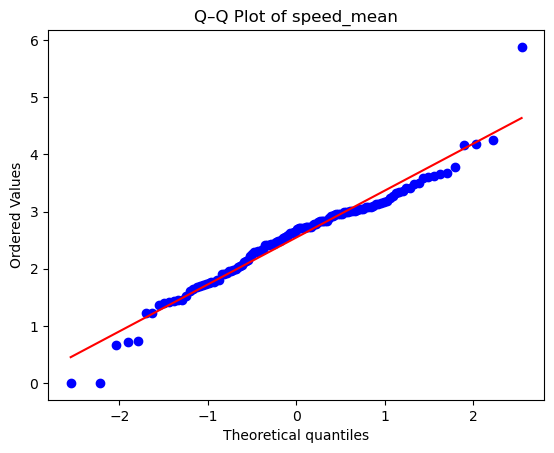

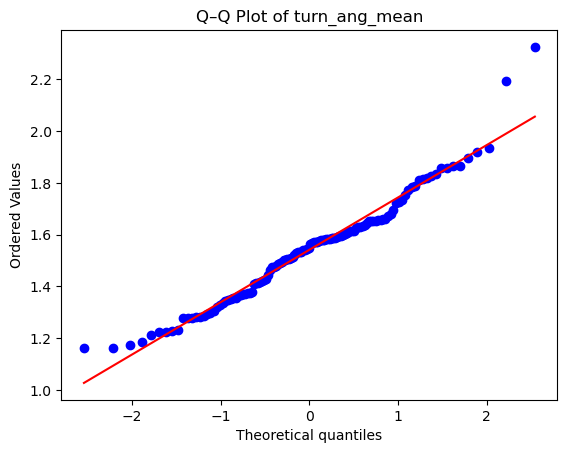

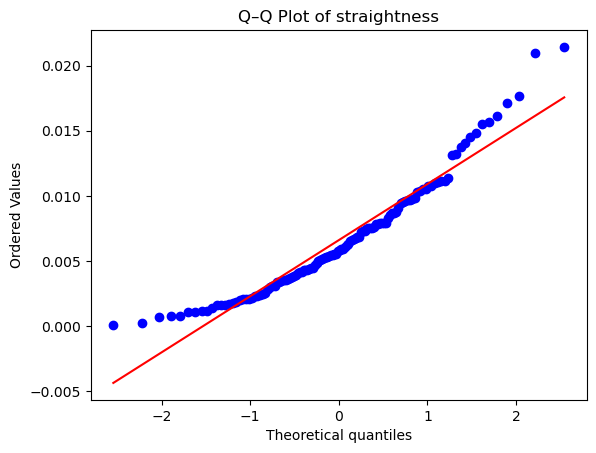

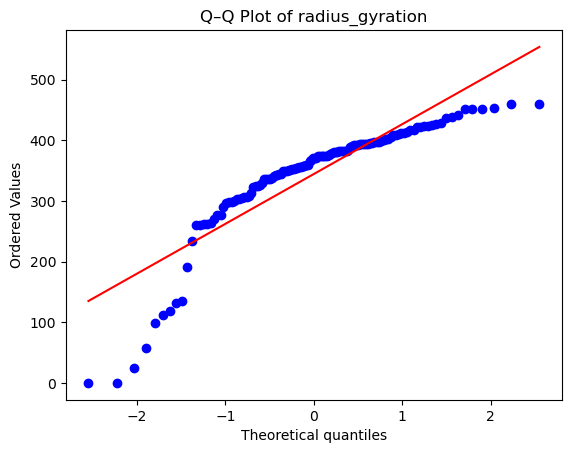

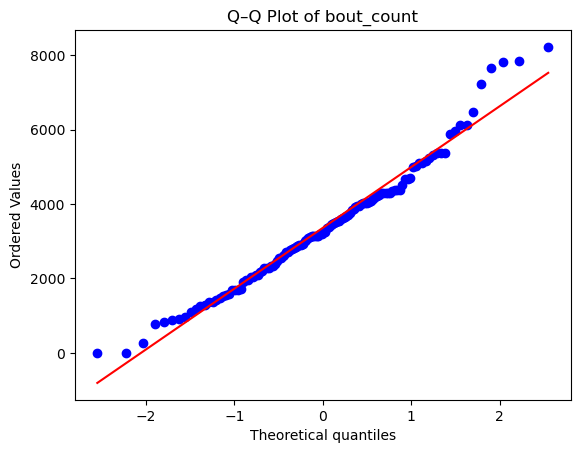

In [7]:
import matplotlib.pyplot as plt
import scipy.stats as stats

for col in ["speed_mean", "turn_ang_mean", "straightness", "radius_gyration", "bout_count"]:
    plt.figure()
    stats.probplot(df[col].dropna(), dist="norm", plot=plt)
    plt.title(f"Q–Q Plot of {col}")
    plt.show()


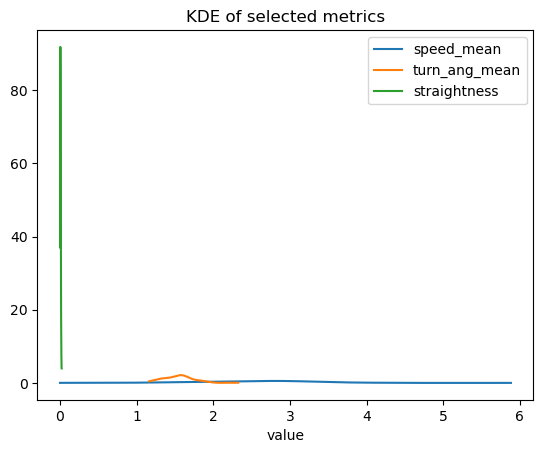

In [8]:
plt.figure()
for col in ["speed_mean", "turn_ang_mean", "straightness"]:
    density = stats.gaussian_kde(df[col].dropna())
    xs = np.linspace(df[col].min(), df[col].max(), 200)
    plt.plot(xs, density(xs), label=col)
plt.legend()
plt.title("KDE of selected metrics")
plt.xlabel("value")
plt.show()


/tmp/ipykernel_495653/648444668.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


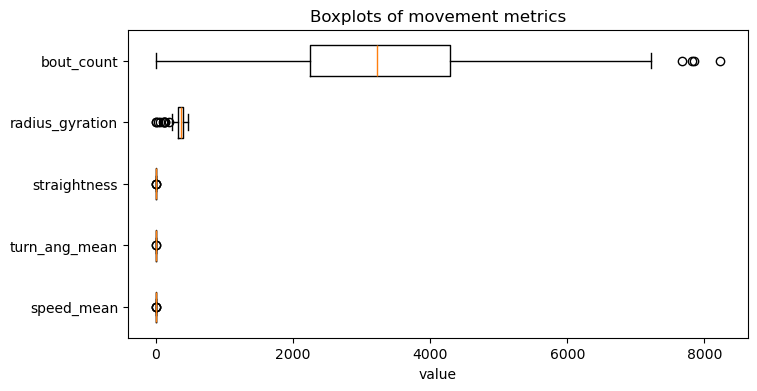

In [12]:
# if you defined metrics as a list of (title, column)
metrics = [
    ("Mean Speed",        "speed_mean"),
    ("Mean Turn Angle",   "turn_ang_mean"),
    ("Straightness",      "straightness"),
    ("Radius of Gyration","radius_gyration"),
    ("Bout Count",        "bout_count")
]

# extract just the column names
cols = [col for _, col in metrics]

plt.figure(figsize=(8,4))
plt.boxplot(
    [df[c].dropna() for c in cols],
    labels=cols,    # or use the titles [t for t,_ in metrics] if you prefer
    vert=False
)
plt.title("Boxplots of movement metrics")
plt.xlabel("value")
plt.show()


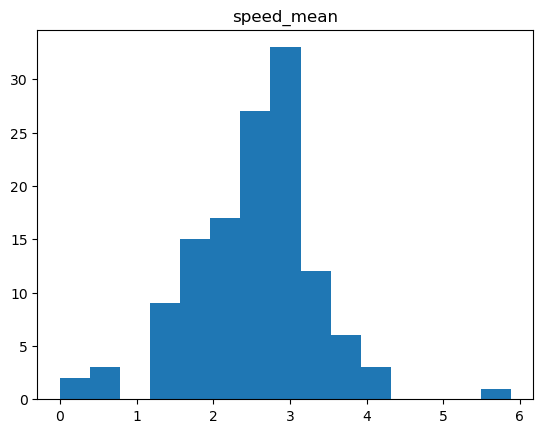

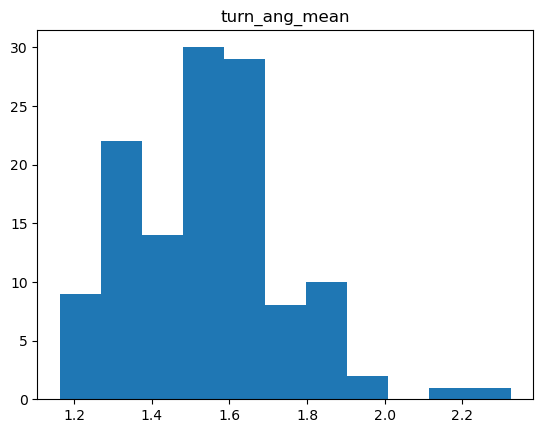

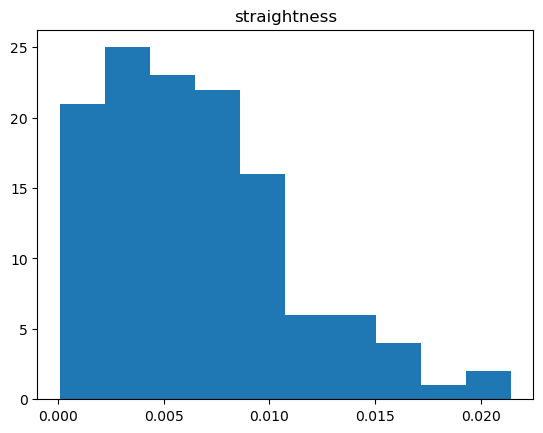

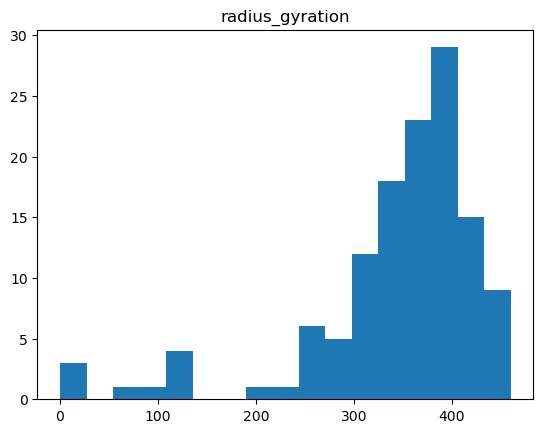

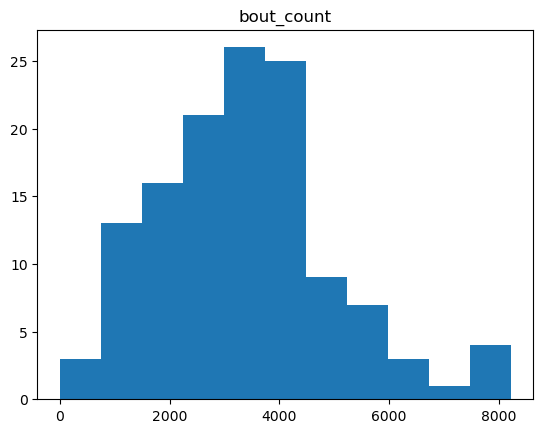

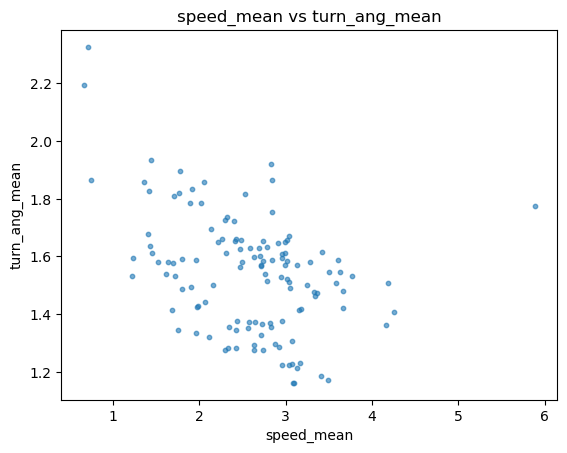

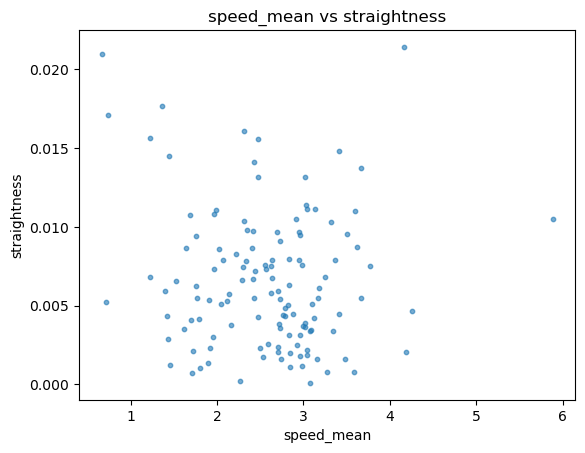

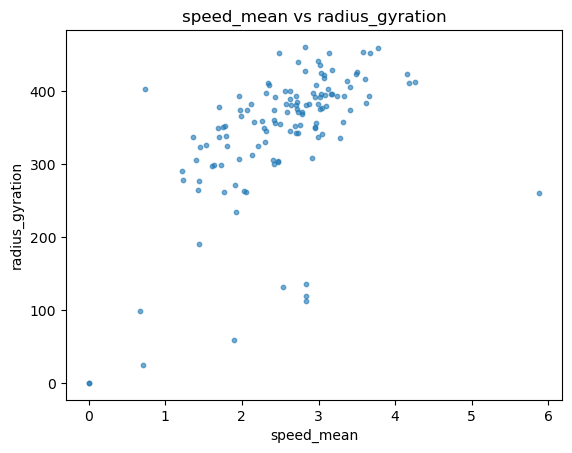

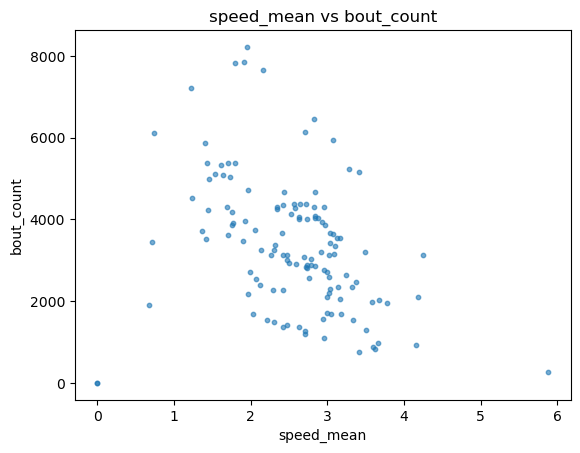

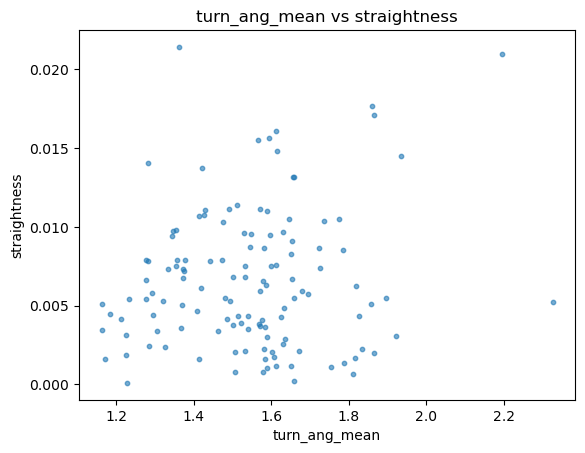

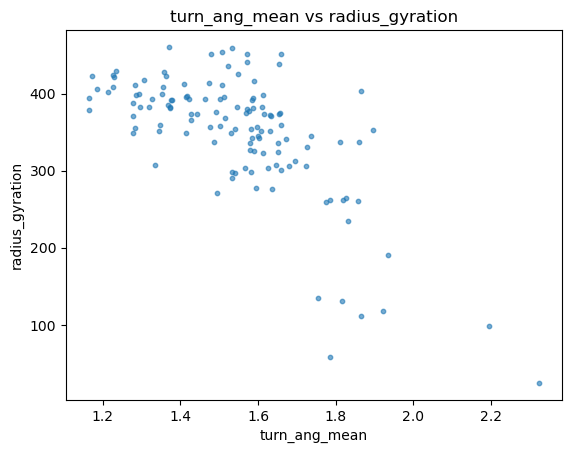

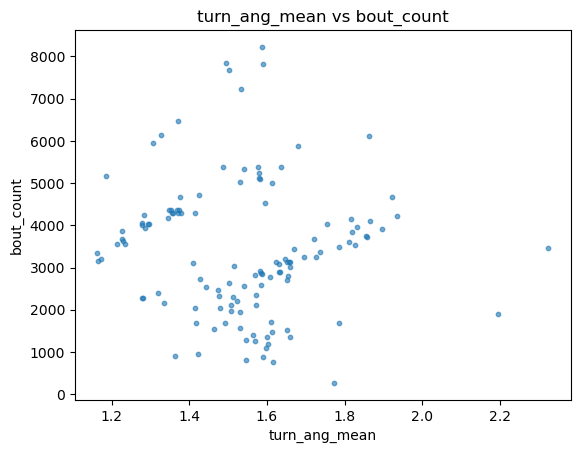

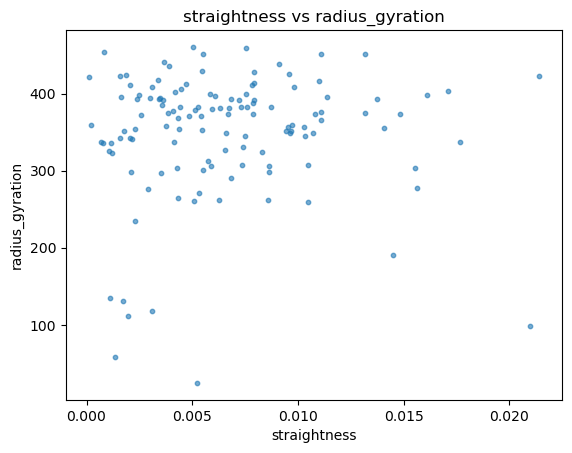

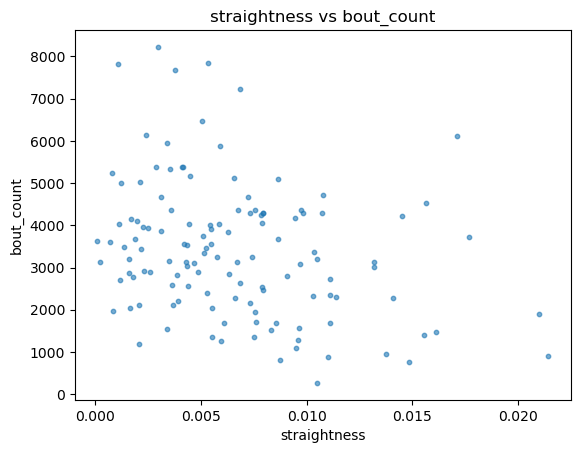

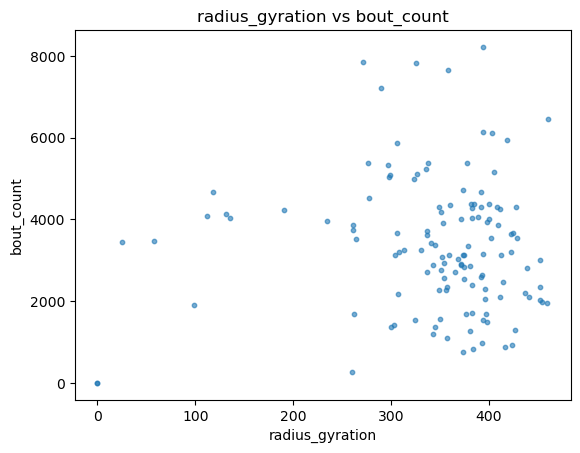

In [16]:
import itertools
import matplotlib.pyplot as plt

# your original metrics list
metrics = [
    ("Mean Speed",        "speed_mean"),
    ("Mean Turn Angle",   "turn_ang_mean"),
    ("Straightness",      "straightness"),
    ("Radius of Gyration","radius_gyration"),
    ("Bout Count",        "bout_count")
]

# 1) get only the column keys
cols = [col for _, col in metrics]

# 2) histogram example (just using cols)
for c in cols:
    plt.figure()
    plt.hist(df[c].dropna(), bins="auto")
    plt.title(c)
    plt.show()

# 3) pairwise scatter
for x, y in itertools.combinations(cols, 2):
    plt.figure()
    plt.scatter(df[x], df[y], s=10, alpha=0.6)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f"{x} vs {y}")
    plt.show()


# pairs = list(itertools.combinations(cols, 2))
# n = len(pairs)
# plt.figure(figsize=(6, 4*n))
# for i, (x, y) in enumerate(pairs, 1):
#     ax = plt.subplot(n, 1, i)
#     ax.scatter(df[x], df[y], s=10, alpha=0.6)
#     ax.set_xlabel(x)
#     ax.set_ylabel(y)
#     ax.set_title(f"{x} vs {y}")
# plt.tight_layout()
# plt.show()


In [29]:
#!/usr/bin/env python3
import os
import scipy.io as sio
import numpy as np
import pandas as pd

# ——— PARAMETERS ———
csv_file     = "/home/lq53/mir_repos/dappy_24_nov/mir_modif_dappy/meta_datas/merged_full_250715.csv"
speed_thresh = 0.5  # threshold for defining a movement bout

# ——— HELPERS ———
def get_session_root(pred_path):
    # from .../DANNCE/predict00/... go up three levels
    return os.path.abspath(
        os.path.join(pred_path, os.pardir, os.pardir, os.pardir)
    )

def get_com_path(session_root):
    return os.path.join(session_root, "COM", "predict00", "com3d0.mat")

def segment_bouts(com, speed_thresh):
    speeds = np.linalg.norm(np.diff(com, axis=0), axis=1)
    bouts = 0
    in_bout = False
    for s in speeds:
        if s > speed_thresh and not in_bout:
            bouts += 1
            in_bout = True
        elif s <= speed_thresh:
            in_bout = False
    return bouts

# ——— MAIN ———
# 1. load metadata (no sessions excluded)
meta = pd.read_csv(csv_file)
baseline = meta.copy()  # include every session

records = []
session_count = 0
fps = 30.0
dt  = 1.0 / fps   # ≈0.0333 s
for _, row in baseline.iterrows():
    session_count += 1
    pred = row["Prediction_path"]
    sess = get_session_root(pred)
    com_f = get_com_path(sess)

    try:
        mat = sio.loadmat(com_f)
        com = mat["com"]   # shape (T,3)
    except Exception as e:
        print(f"Skipping {sess!r}: {e}")
        continue

    # compute step displacements
    dxyz = np.diff(com, axis=0)
    speeds = np.linalg.norm(dxyz, axis=1) / dt

    # 1. Mean speed
    speed_mean = speeds.mean()

    # 2. Mean turn angle
    if dxyz.shape[0] >= 2:
        v1, v2 = dxyz[:-1], dxyz[1:]
        n1, n2 = np.linalg.norm(v1, axis=1), np.linalg.norm(v2, axis=1)
        valid = (n1 > 0) & (n2 > 0)
        cosang = np.einsum("ij,ij->i", v1[valid], v2[valid]) / (n1[valid] * n2[valid])
        turn_ang_mean = np.arccos(np.clip(cosang, -1, 1)).mean()
    else:
        turn_ang_mean = np.nan

    # 3. Straightness
    total_dist = speeds.sum()
    net_disp   = np.linalg.norm(com[-1] - com[0])
    straightness = net_disp / total_dist if total_dist > 0 else np.nan

    # 4. Radius of gyration
    center = com.mean(axis=0)
    rg     = np.sqrt(np.mean(np.sum((com - center) ** 2, axis=1)))

    # 5. Bout count
    bout_count = segment_bouts(com, speed_thresh)

    records.append({
        "session_root": sess,
        "speed_mean": speed_mean,
        "turn_ang_mean": turn_ang_mean,
        "straightness": straightness,
        "radius_gyration": rg,
        "bout_count": bout_count,
    })

# assemble and display
df = pd.DataFrame.from_records(records)
print("COM movement metrics (all sessions):")
print(df.to_string(index=False))

# save for downstream use
out_file = "com_all_sessions_metrics.csv"
df.to_csv(out_file, index=False)
print(f"\nSaved metrics to {out_file}")

print("session_count", session_count)


/tmp/ipykernel_495653/2680886476.py:68: RuntimeWarning: Mean of empty slice.
  turn_ang_mean = np.arccos(np.clip(cosang, -1, 1)).mean()
/home/lq53/miniconda3/envs/bbop241209/lib/python3.9/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Skipping '/home/lq53/mir_repos/BBOP': [Errno 2] No such file or directory: '/home/lq53/mir_repos/BBOP/COM/predict00/com3d0.mat'
COM movement metrics (all sessions):
                                                                                session_root  speed_mean  turn_ang_mean  straightness  radius_gyration  bout_count
                                  /data/big_rim/rsync_dcc_sum/24summ/2024_06_26/1686940_left  102.212954       1.185668      0.000149     4.053829e+02        5165
                                 /data/big_rim/rsync_dcc_sum/24summ/2024_06_26/1686940_left2   57.268944       1.495061      0.000178     2.708663e+02        7854
                              /data/big_rim/rsync_dcc_sum/24summ/2024_06_26/1686940_no_holes   81.273925       1.327535      0.000079     3.932853e+02        6131
                                  /data/big_rim/rsync_dcc_sum/24summ/2024_06_27/1686941_left   84.713269       1.369670      0.000167     4.605231e+02        6467
                    

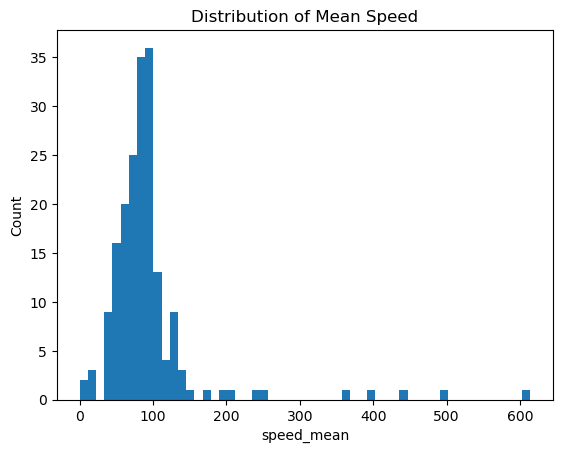

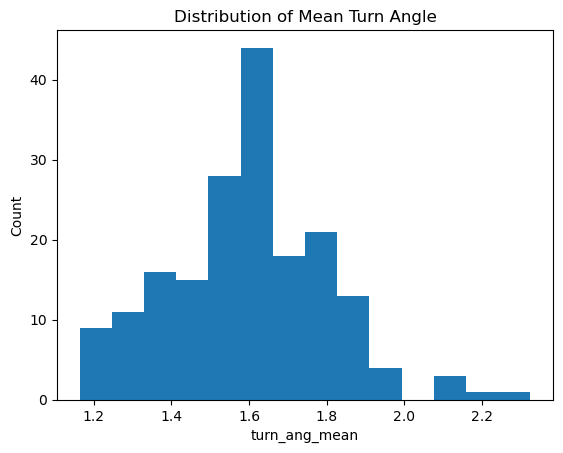

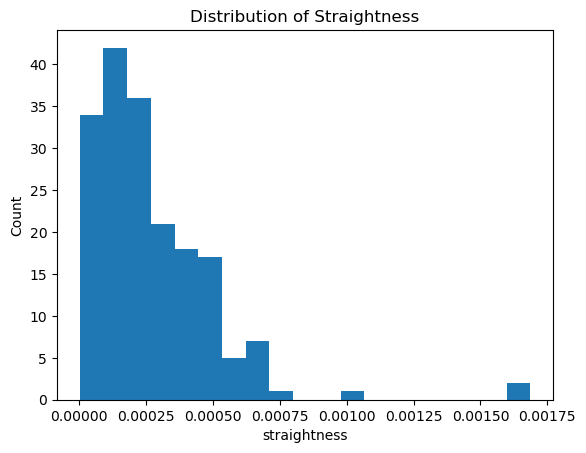

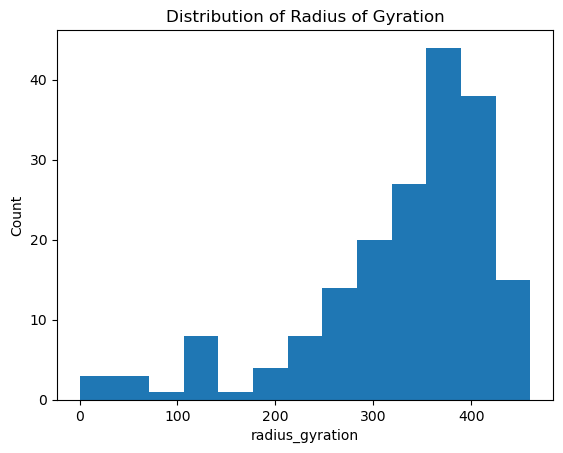

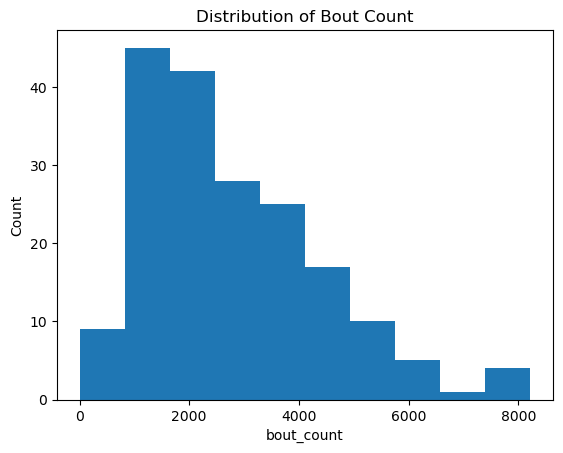

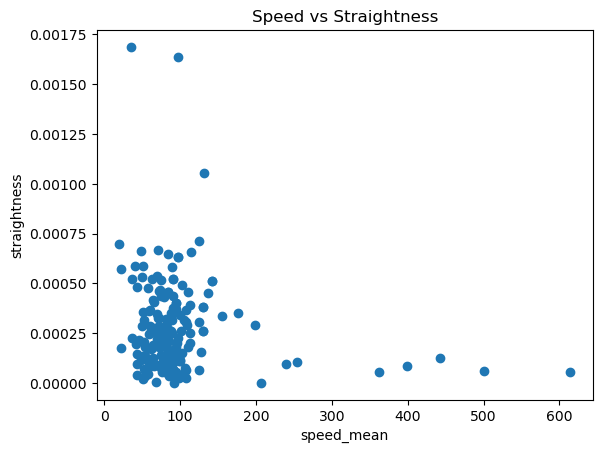

In [30]:
import matplotlib.pyplot as plt

# List of the five metrics
metrics = [
    ("Mean Speed",        "speed_mean"),
    ("Mean Turn Angle",   "turn_ang_mean"),
    ("Straightness",      "straightness"),
    ("Radius of Gyration","radius_gyration"),
    ("Bout Count",        "bout_count")
]

# 1) Histograms
for title, col in metrics:
    plt.figure()
    plt.hist(df[col].dropna(), bins='auto')
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.title(f"Distribution of {title}")
    plt.show()

# 2) Example bivariate scatter: Speed vs Straightness
plt.figure()
plt.scatter(df["speed_mean"], df["straightness"])
plt.xlabel("speed_mean")
plt.ylabel("straightness")
plt.title("Speed vs Straightness")
plt.show()


In [21]:
import pandas as pd
from scipy.stats import skew, kurtosis

# assume df is already in memory
summary = []
for col in ["speed_mean", "turn_ang_mean", "straightness", "radius_gyration", "bout_count"]:
    data = df[col].dropna()
    summary.append({
        "metric":       col,
        "mean":         data.mean(),
        "median":       data.median(),
        "std":          data.std(ddof=1),
        "skewness":     skew(data),
        "kurtosis":     kurtosis(data, fisher=True),  # excess kurtosis
    })
pd.DataFrame(summary).set_index("metric")


,mean,median,std,skewness,kurtosis
metric,,,,,
speed_mean,3.146145,2.801156,2.389549,4.441254,23.891503
turn_ang_mean,1.598565,1.589563,0.207630,0.253359,0.330571
straightness,0.008171,0.006722,0.006985,2.695269,12.401616
radius_gyration,330.070872,356.693157,95.059294,-1.413315,1.873990
bout_count,2771.666667,2313.500000,1629.969708,0.947932,0.760519


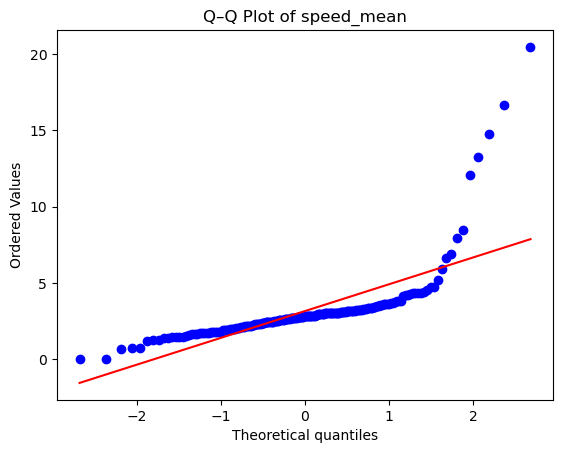

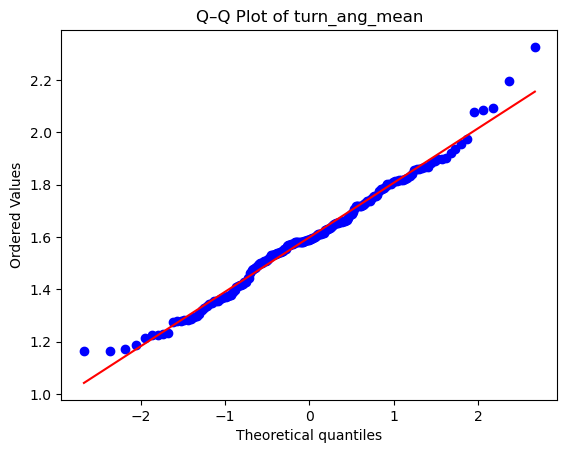

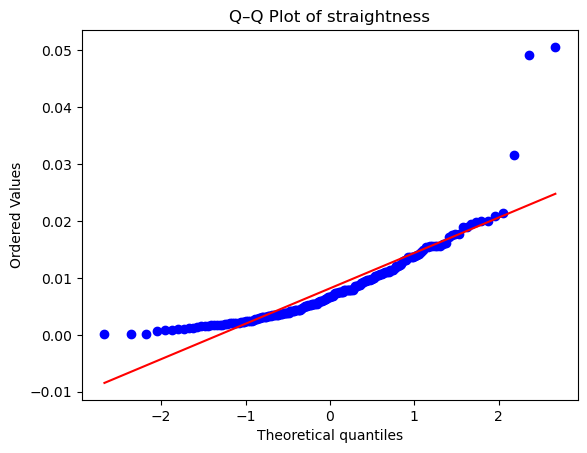

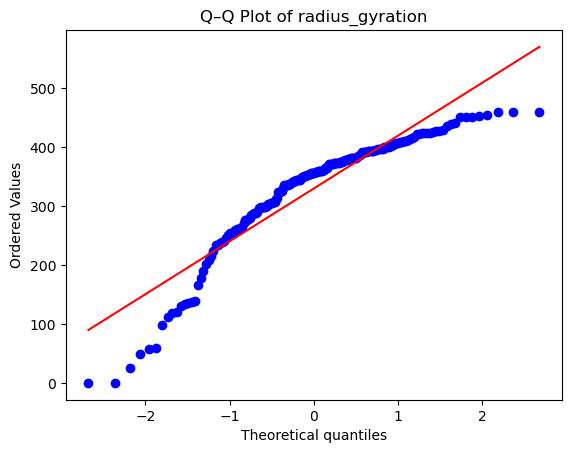

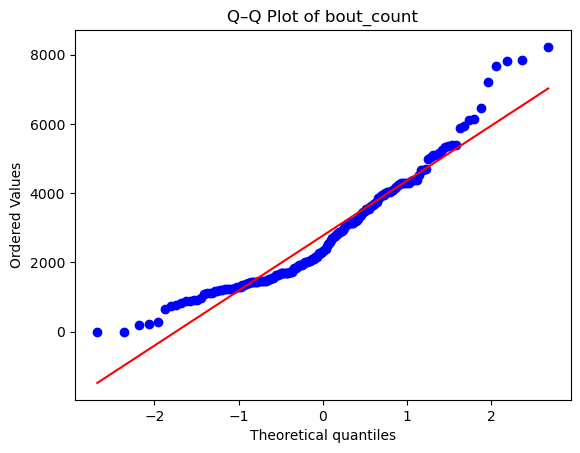

In [22]:
import matplotlib.pyplot as plt
import scipy.stats as stats

for col in ["speed_mean", "turn_ang_mean", "straightness", "radius_gyration", "bout_count"]:
    plt.figure()
    stats.probplot(df[col].dropna(), dist="norm", plot=plt)
    plt.title(f"Q–Q Plot of {col}")
    plt.show()


/tmp/ipykernel_495653/648444668.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


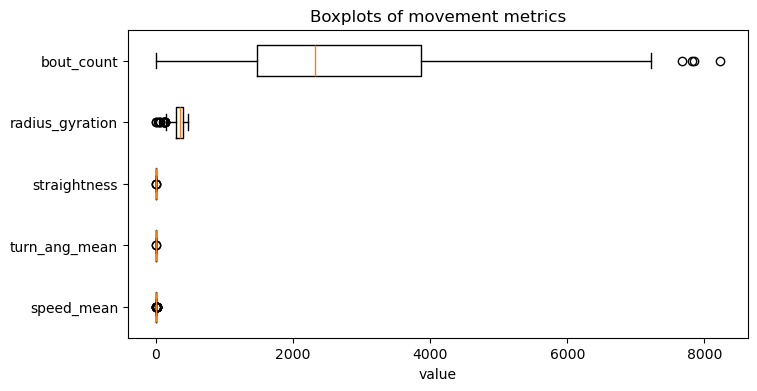

In [23]:
# if you defined metrics as a list of (title, column)
metrics = [
    ("Mean Speed",        "speed_mean"),
    ("Mean Turn Angle",   "turn_ang_mean"),
    ("Straightness",      "straightness"),
    ("Radius of Gyration","radius_gyration"),
    ("Bout Count",        "bout_count")
]

# extract just the column names
cols = [col for _, col in metrics]

plt.figure(figsize=(8,4))
plt.boxplot(
    [df[c].dropna() for c in cols],
    labels=cols,    # or use the titles [t for t,_ in metrics] if you prefer
    vert=False
)
plt.title("Boxplots of movement metrics")
plt.xlabel("value")
plt.show()
